In [11]:
import torch
import torch.nn as nn
import numpy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
%matplotlib inline
import nibabel as nib

In [19]:
# load file
file_path = "../data/BraTS2021_00131/BraTS2021_00131_flair.nii.gz"
img = nib.load(file_path) 
img_data = img.get_fdata()

ground_truth_path = "../data/BraTS2021_00131/BraTS2021_00131_seg.nii.gz"
ground_truth_img = nib.load(ground_truth_path) 
ground_truth_data = ground_truth_img.get_fdata()

In [9]:
# file format
print("Type: ", type(img_data))
print("Shape: ", img_data.shape)

Type:  <class 'numpy.ndarray'>
Shape:  (240, 240, 155)


Slice shape:  (240, 240)


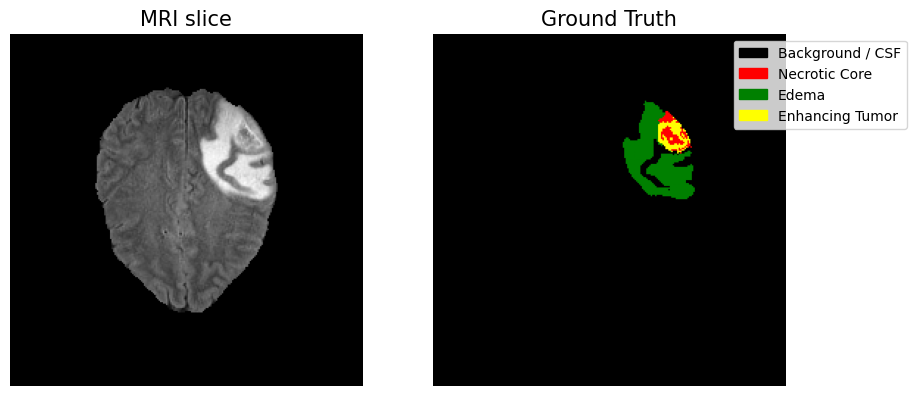

In [22]:
data_slice = img_data[: ,:, 100]
ground_truth_slice = ground_truth_data[:, :, 100]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
print("Slice shape: ", data_slice.shape)
plt.imshow(data_slice.T, cmap='gray', origin='lower')
plt.axis('off')
plt.title("MRI slice", fontsize=15)

# Black - CSF (healthy tissue) + Placeholder for label 3, which is non-existent in BraTS dataset
# Red - Necrotic core (label 1)
# Green - Edema (label 2)
# Yellow - Enhancing tumour (label 4)
colors = ["black", "red", "green", "black", "yellow"]
cmap = mcolors.ListedColormap(colors)

plt.subplot(1, 2, 2)
plt.imshow(ground_truth_slice.T, cmap=cmap, vmin=0, vmax=4, origin='lower')
plt.axis('off')
plt.title("Ground Truth", fontsize=15)

key_bg = mpatches.Patch(color="black", label="Background / CSF")
key_ncr = mpatches.Patch(color="red", label="Necrotic Core")
key_ed = mpatches.Patch(color="green", label="Edema")
key_et = mpatches.Patch(color="yellow", label="Enhancing Tumor")

plt.legend(
    handles=[key_bg, key_ncr, key_ed, key_et],
    bbox_to_anchor=(1.1, 1),
    loc="upper center",
)

In [ ]:
class SingleEncoderBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=input_channels,
            out_channels=output_channels, 
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        ) # We don't need bias if we have batch normalisation 
        self.batch_norm1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(
            in_channels=output_channels,
            out_channels=output_channels, 
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.batch_norm2 = nn.BatchNorm2d(output_channels)
        self.activation_fun = nn.ReLU()
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.activation_fun(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.activation_fun(x)

        p = self.pool(x)
        return x, p

In [ ]:
class SingleDecoderBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.up_conv = nn.ConvTranspose2d(
            in_channels=input_channels,
            out_channels=output_channels, 
            kernel_size=2,
            stride=2
        ) # Mirrors the pooling layers from encoder 

        self.conv1 = nn.Conv2d(
            in_channels=output_channels *2,
            out_channels=output_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.batch_norm1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(
            in_channels=output_channels,
            out_channels=output_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.batch_norm2 = nn.BatchNorm2d(output_channels)
        self.activation_fun = nn.ReLU()
    
    def forward(self, input, skip_layer_input):
        input = self.up_conv(input)
        merged = torch.cat([input, skip_layer_input], axis=1)

        x = self.conv1(merged)
        x = self.batch_norm1(x)
        x = self.activation_fun(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.activation_fun(x)

        return x



In [ ]:
class Full2DUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder1 = SingleEncoderBlock()
        self.encoder2 = SingleEncoderBlock()
        self.encoder3 = SingleEncoderBlock()
        self.encoder4 = SingleEncoderBlock()

        self.bottleneck = nn.Sequential(
            nn.Conv2d(),
            nn.BatchNorm2d(),
            nn.Conv2d(),
            nn.BatchNorm2d(),
            nn.ReLU()
        )

        self.decoder1 = SingleDecoderBlock()
        self.decoder2 = SingleDecoderBlock()
        self.decoder3 = SingleDecoderBlock()
        self.decoder4 = SingleDecoderBlock()
        
        self.output_layer = nn.Conv2D()

    def forward(self,input):
        x1, p1 = self.encoder1(input)
        x2, p2 = self.encoder2(p1)
        x3, p3 = self.encoder3(p2)
        x4, p4 = self.encoder4(p3)

        b = self.bottleneck(p4)

        d1 = self.decoder1(b, x4)
        d2 = self.decoder2(d1, x3)
        d3 = self.decoder3(d2, x2)
        d4 = self.decoder4(d3, x1)

        output = self.output_layer(d4)

        return output